In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def read_csv_data (path):
    df = pd.read_csv(path)
    return df
def read_excel_data (path):
    df = pd.read_excel(path)
    return df


In [4]:
path = "bank.csv"
df = read_csv_data(path)

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [26]:
def descripe_data (df):
    print("shape of data :: ",df.shape , "\n\n")
    print("columns of data :: " , df.columns , "\n\n")
    print(df.info() , "\n\n")
    print(df.describe() ,"\n\n")

descripe_data(df)

shape of data ::  (11162, 17) 


columns of data ::  Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object') 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  

In [ ]:
def select_columns (df):
    numerical_columns = df.select_dtypes(include=[np.number]).columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    return numerical_columns,categorical_columns
    
numerical_columns , categorical_columns = select_columns(df)

In [93]:
print("numerical columns -> " , numerical_columns)


numerical columns ->  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [94]:
print("categorical columns -> " , categorical_columns)

categorical columns ->  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


In [87]:
def missing_values(df):
    rows_with_missing_values = df[df.isnull().any(axis=1)]
    sum_of_missing_values = df.isnull().sum()
    percentage_of_missing_values = (sum_of_missing_values / len(df)) * 100
    return rows_with_missing_values , sum_of_missing_values , percentage_of_missing_values

rows_with_missing_values , sum_of_missing_values , percentage_of_missing_values  = missing_values(df)

In [88]:
print("\nrows with missing_values >>>>\n\n", rows_with_missing_values)


rows with missing_values >>>>

 Empty DataFrame
Columns: [age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, deposit]
Index: []


In [89]:
table = pd.DataFrame({
    'Column Name': df.columns, 
    'Missing Values': sum_of_missing_values, 
    'Percentage (%)': percentage_of_missing_values
})

table

,Column Name,Missing Values,Percentage (%)
age,age,0,0.0
job,job,0,0.0
marital,marital,0,0.0
education,education,0,0.0
default,default,0,0.0
balance,balance,0,0.0
housing,housing,0,0.0
loan,loan,0,0.0
contact,contact,0,0.0
day,day,0,0.0


In [ ]:
def datatype_conversion( df , columns , datatype ):
    df[columns].astype(datatype)

In [104]:
def drop_columns (df , percentage_of_missing_values, threshold): 
    for i , per in enumerate(percentage_of_missing_values):
        if per > threshold:
            print(f"{df.columns[i]} has {per:.2f}% of missing values.")
            df.drop(columns=df.columns[i], inplace=True)
            print(f"{df.columns[i]} has been dropped from the dataset.")
    print(f"columns with {threshold}% missed_values was droped from the dataset")
    return

In [105]:
def drop_rows (df):
    df.dropna(inplace=True)
    print("Rows with missing values have been dropped from the dataset.")
    return

In [106]:
def shape_comparison(df):
    old_shape = df.shape
    drop_columns(df , percentage_of_missing_values , 40)
    drop_rows(df)
    new_shape = df.shape
    print("shape before dropping columns and rows ->>> " , old_shape)
    print("shape after dropping columns and rows ->>> " , new_shape)
    return
shape_comparison(df)

columns with 40% missed_values was droped from the dataset
Rows with missing values have been dropped from the dataset.
shape before dropping columns and rows ->>>  (11162, 17)
shape after dropping columns and rows ->>>  (11162, 17)


In [107]:
def replace_numerical_missing_values (df, numerical_columns):
    for col in numerical_columns:
        mean_value = df[col].mean() 
        df[col].fillna(mean_value, inplace=True)
        print(f"Missing values in {col} have been replaced with the mean value: {mean_value:.2f}")
    return
replace_numerical_missing_values(df, numerical_columns)


Missing values in age have been replaced with the mean value: 41.23
Missing values in balance have been replaced with the mean value: 1528.54
Missing values in day have been replaced with the mean value: 15.66
Missing values in duration have been replaced with the mean value: 371.99
Missing values in campaign have been replaced with the mean value: 2.51
Missing values in pdays have been replaced with the mean value: 51.33
Missing values in previous have been replaced with the mean value: 0.83


In [110]:
def replace_categorical_missing_values (df, categorical_columns):
    for col in categorical_columns:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Missing values in {col} have been replaced with the mode value: {mode_value}")
    return 
replace_categorical_missing_values(df, categorical_columns)

Missing values in job have been replaced with the mode value: management
Missing values in marital have been replaced with the mode value: married
Missing values in education have been replaced with the mode value: secondary
Missing values in default have been replaced with the mode value: no
Missing values in housing have been replaced with the mode value: no
Missing values in loan have been replaced with the mode value: no
Missing values in contact have been replaced with the mode value: cellular
Missing values in month have been replaced with the mode value: may
Missing values in poutcome have been replaced with the mode value: unknown
Missing values in deposit have been replaced with the mode value: no


In [ ]:
def hist (column,figsize,title):
    plt.figure(figsize=figsize)
    plt.hist(column, edgecolor = 'black')
    plt.title(title)
    plt.show()
    return

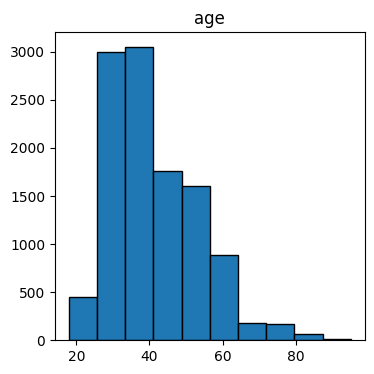

In [153]:
hist(df['age'],(4,4),"age")

In [150]:
def boxplot(column,figsize,title):
    plt.figure(figsize=figsize)
    sns.boxplot(column , orient = 'h')
    plt.title(title)
    plt.show()

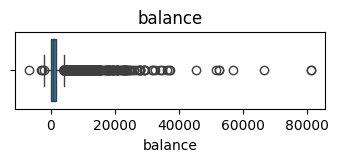

In [151]:
boxplot(df['balance'],(4,1),"balance")

In [ ]:
def kdepolt(column,figsize,title):
    plt.figure(figsize=figsize)
    sns.kdeplot(column, fill=True, edgecolor = 'black')
    plt.title(title)
    plt.show()

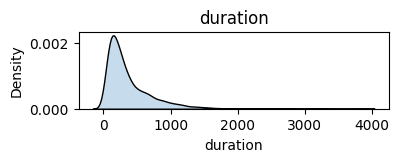

In [155]:
kdepolt(df['duration'],(4,1),"duration")

In [145]:
def countplot(column,figsize,title,df):
    plt.figure(figsize=figsize)
    sns.countplot(x = column , data= df ,  edgecolor = 'black')
    plt.title(title)
    plt.show()

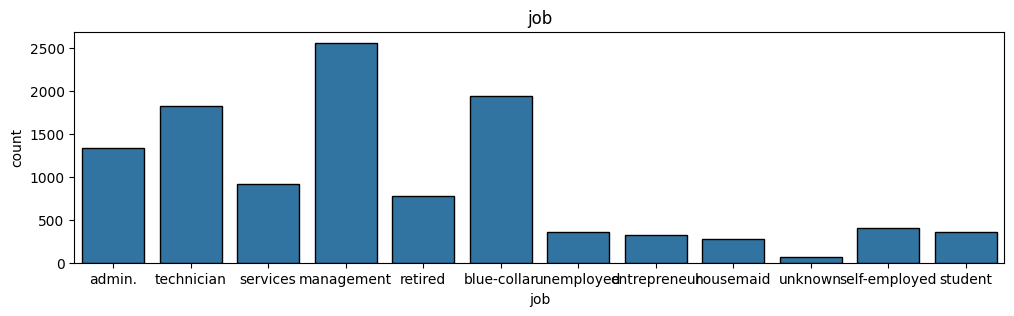

In [146]:
countplot(df["job"],(12,3),"job",df)


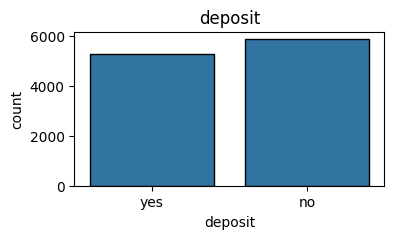

In [156]:
countplot(df["deposit"],(4,2),"deposit",df)

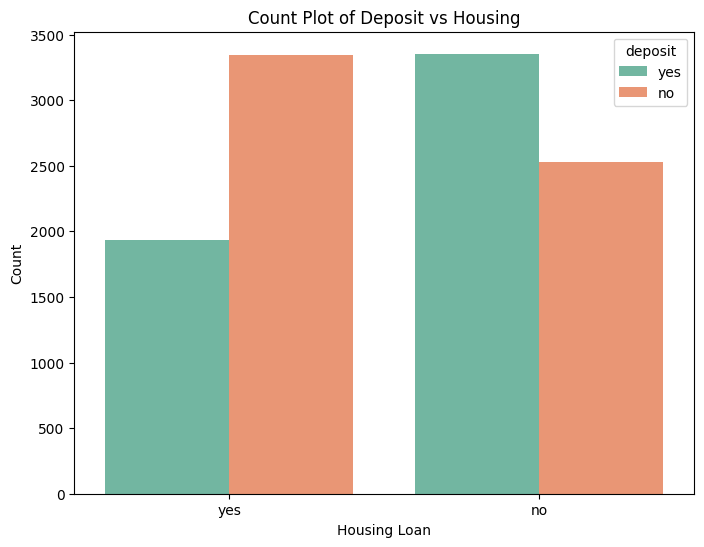

In [154]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='housing', hue='deposit', palette='Set2')
plt.title('Count Plot of Deposit vs Housing')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.show()